In [3]:
import pandas as pd
import numpy as np

df = pd.read_csv("Food_Delivery_Times.csv")

# Clean column names
df.columns = df.columns.str.strip().str.replace(" ", "_").str.lower()

df.head()

,order_id,distance_km,weather,traffic_level,time_of_day,vehicle_type,preparation_time_min,courier_experience_yrs,delivery_time_min
0,522,7.93,Windy,Low,Afternoon,Scooter,12,1.0,43
1,738,16.42,Clear,Medium,Evening,Bike,20,2.0,84
2,741,9.52,Foggy,Low,Night,Scooter,28,1.0,59
3,661,7.44,Rainy,Medium,Afternoon,Scooter,5,1.0,37
4,412,19.03,Clear,Low,Morning,Bike,16,5.0,68


In [4]:
# Drop duplicate orders
df = df.drop_duplicates(subset='order_id', keep='first')

# Remove rows where Delivery_Time_min is missing
df = df[df['delivery_time_min'].notnull()]

# Fill missing weather, traffic, and time of day with mode
for col in ['weather', 'traffic_level', 'time_of_day', 'vehicle_type']:
    if col in df.columns:
        df[col] = df[col].fillna(df[col].mode()[0])

# Fill numeric missing with median
for col in ['distance_km', 'preparation_time_min', 'courier_experience_yrs']:
    if col in df.columns:
        df[col] = df[col].fillna(df[col].median())

In [5]:
# Weather one-hot encoding
weather_dummies = pd.get_dummies(df['weather'], prefix='weather')
df = pd.concat([df, weather_dummies], axis=1)

In [6]:
traffic_map = {'Low': 1, 'Medium': 2, 'High': 3}
df['traffic_intensity'] = df['traffic_level'].map(traffic_map)

In [7]:
vehicle_dummies = pd.get_dummies(df['vehicle_type'], prefix='vehicle')
df = pd.concat([df, vehicle_dummies], axis=1)

In [8]:
# Distance × Traffic
# Because long distance + heavy traffic = longer delivery
df['distance_traffic_interaction'] = df['distance_km'] * df['traffic_intensity']

# Experience × Traffic
# More experienced riders handle traffic better.
df['experience_traffic_interaction'] = df['courier_experience_yrs'] * df['traffic_intensity']

# Time of day × Traffic
# Evening + High traffic = big delays
# df['timeofday_traffic_interaction'] = df['time_of_day_code'] * df['traffic_intensity']

In [11]:
df['log_distance'] = np.log1p(df['distance_km'])

In [12]:
target = "delivery_time_min"

features = [
    'distance_km',
    'log_distance',
    'traffic_intensity',
    # 'time_of_day_code',
    'preparation_time_min',
    'courier_experience_yrs',
    'distance_traffic_interaction',
    'experience_traffic_interaction',
    # 'timeofday_traffic_interaction'
]

# Add weather one-hot columns
features += [col for col in df.columns if col.startswith('weather_')]

# Add vehicle type one-hot columns
features += [col for col in df.columns
             if col.startswith('vehicle_') and col != 'vehicle_type']

df_model = df[features + [target]]

df_model.head()

,distance_km,log_distance,traffic_intensity,preparation_time_min,courier_experience_yrs,distance_traffic_interaction,experience_traffic_interaction,weather_Clear,weather_Foggy,weather_Rainy,weather_Snowy,weather_Windy,vehicle_Bike,vehicle_Car,vehicle_Scooter,delivery_time_min
0,7.93,2.189416,1,12,1.0,7.93,1.0,False,False,False,False,True,False,False,True,43
1,16.42,2.857619,2,20,2.0,32.84,4.0,True,False,False,False,False,True,False,False,84
2,9.52,2.353278,1,28,1.0,9.52,1.0,False,True,False,False,False,False,False,True,59
3,7.44,2.132982,2,5,1.0,14.88,2.0,False,False,True,False,False,False,False,True,37
4,19.03,2.997231,1,16,5.0,19.03,5.0,True,False,False,False,False,True,False,False,68


In [13]:
# Identify categorical columns
cat_cols = df_model.select_dtypes(include=['object']).columns

# One-hot encode them
df_model = pd.get_dummies(df_model, columns=cat_cols, drop_first=True)

In [14]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

X = df_model[features]
y = df_model[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [15]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

print("Linear Regression RMSE:", mean_squared_error(y_test, y_pred_lr))
print("Linear Regression R2:", r2_score(y_test, y_pred_lr))

Linear Regression RMSE: 77.2846011617778
Linear Regression R2: 0.8275770860025151


In [16]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("Random Forest RMSE:", mean_squared_error(y_test, y_pred_rf))
print("Random Forest R2:", r2_score(y_test, y_pred_rf))

Random Forest RMSE: 96.1500365
Random Forest R2: 0.7854880632741927


In [17]:
!pip install xgboost

In [18]:
from xgboost import XGBRegressor

xgb = XGBRegressor(
    n_estimators=300, learning_rate=0.1, max_depth=6,
    subsample=0.8, colsample_bytree=0.8, random_state=42
)

xgb.fit(X_train, y_train)
y_pred_xgb = xgb.predict(X_test)

print("XGBoost RMSE:", mean_squared_error(y_test, y_pred_xgb))
print("XGBoost R2:", r2_score(y_test, y_pred_xgb))

XGBoost RMSE: 110.47820281982422
XGBoost R2: 0.753521740436554


In [19]:
import numpy as np
import pandas as pd

def create_input_row(distance_km, weather, traffic_level, vehicle_type,
                     preparation_time_min, courier_experience_yrs):

    # Base numeric features
    data = {
        'distance_km': [distance_km],
        'log_distance': [np.log1p(distance_km)],
        'traffic_intensity': [ {'Low':1,'Medium':2,'High':3}[traffic_level] ],
        'preparation_time_min': [preparation_time_min],
        'courier_experience_yrs': [courier_experience_yrs],
        'distance_traffic_interaction': [distance_km * {'Low':1,'Medium':2,'High':3}[traffic_level]],
        'experience_traffic_interaction': [courier_experience_yrs * {'Low':1,'Medium':2,'High':3}[traffic_level]],
    }

    # Add weather one-hot columns
    for col in [c for c in X.columns if c.startswith("weather_")]:
        data[col] = [1 if col == f"weather_{weather}" else 0]

    # Add vehicle one-hot columns (not vehicle_type original)
    for col in [c for c in X.columns if (c.startswith("vehicle_") and c != "vehicle_type")]:
        data[col] = [1 if col == f"vehicle_{vehicle_type}" else 0]

    return pd.DataFrame(data)

In [22]:
def predict_with_model(model, distance_km, weather, traffic_level,
                       vehicle_type, preparation_time_min, courier_experience_yrs):

    row = create_input_row(distance_km, weather, traffic_level, vehicle_type,
                           preparation_time_min, courier_experience_yrs)

    prediction = model.predict(row)[0]
    return round(prediction, 2)

In [23]:
predict_with_model(rf,
    distance_km=5,
    weather="Clear",
    traffic_level="Medium",
    vehicle_type="Bike",
    preparation_time_min=12,
    courier_experience_yrs=2
)

np.float64(36.0)

In [24]:
predict_with_model(rf,
    distance_km=6,
    weather="Rainy",
    traffic_level="High",
    vehicle_type="Scooter",
    preparation_time_min=10,
    courier_experience_yrs=3
)

np.float64(45.06)

In [25]:
predict_with_model(rf,
    distance_km=10,
    weather="Clear",
    traffic_level="Low",
    vehicle_type="Car",
    preparation_time_min=15,
    courier_experience_yrs=1
)

np.float64(49.18)

In [26]:
def compare_models(distance_km, weather, traffic_level, vehicle_type,
                   preparation_time_min, courier_experience_yrs):

    print("\nPrediction Comparison\n----------------------")

    print("Linear Regression:",
          predict_with_model(lr, distance_km, weather, traffic_level, vehicle_type,
                             preparation_time_min, courier_experience_yrs))

    print("Random Forest:",
          predict_with_model(rf, distance_km, weather, traffic_level, vehicle_type,
                             preparation_time_min, courier_experience_yrs))

    print("XGBoost:",
          predict_with_model(xgb, distance_km, weather, traffic_level, vehicle_type,
                             preparation_time_min, courier_experience_yrs))

In [27]:
compare_models(
    distance_km=7,
    weather="Foggy",
    traffic_level="High",
    vehicle_type="Scooter",
    preparation_time_min=14,
    courier_experience_yrs=1
)


Prediction Comparison
----------------------
Linear Regression: 57.69
Random Forest: 62.39
XGBoost: 66.93


In [29]:
import matplotlib.pyplot as plt
import seaborn as sns

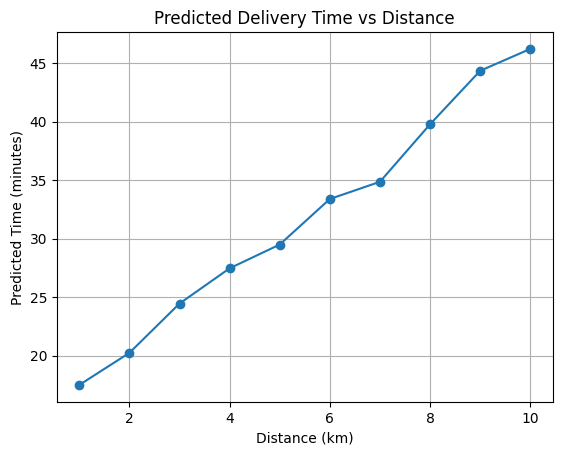

In [30]:
dist = np.arange(1, 11)
preds = [predict_with_model(rf, d, "Clear", "Low", "Bike", 10, 2) for d in dist]

plt.plot(dist, preds, marker='o')
plt.title("Predicted Delivery Time vs Distance")
plt.xlabel("Distance (km)")
plt.ylabel("Predicted Time (minutes)")
plt.grid(True)
plt.show()

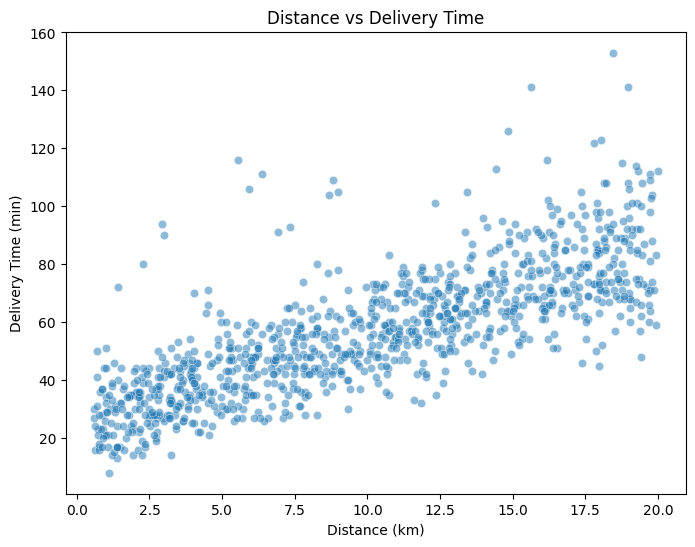

In [ ]:
plt.figure(figsize=(8,6))
sns.scatterplot(x=df['distance_km'], y=df['delivery_time_min'], alpha=0.5)
plt.title("Distance vs Delivery Time")
plt.xlabel("Distance (km)")
plt.ylabel("Delivery Time (min)")
plt.show()

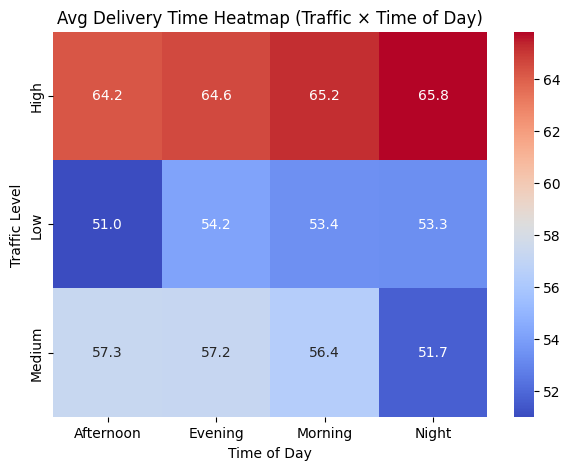

In [ ]:
heat = pd.crosstab(df['traffic_level'], df['time_of_day'],
                   values=df['delivery_time_min'], aggfunc='mean')

plt.figure(figsize=(7,5))
sns.heatmap(heat, annot=True, fmt=".1f", cmap="coolwarm")
plt.title("Avg Delivery Time Heatmap (Traffic × Time of Day)")
plt.xlabel("Time of Day")
plt.ylabel("Traffic Level")
plt.show()

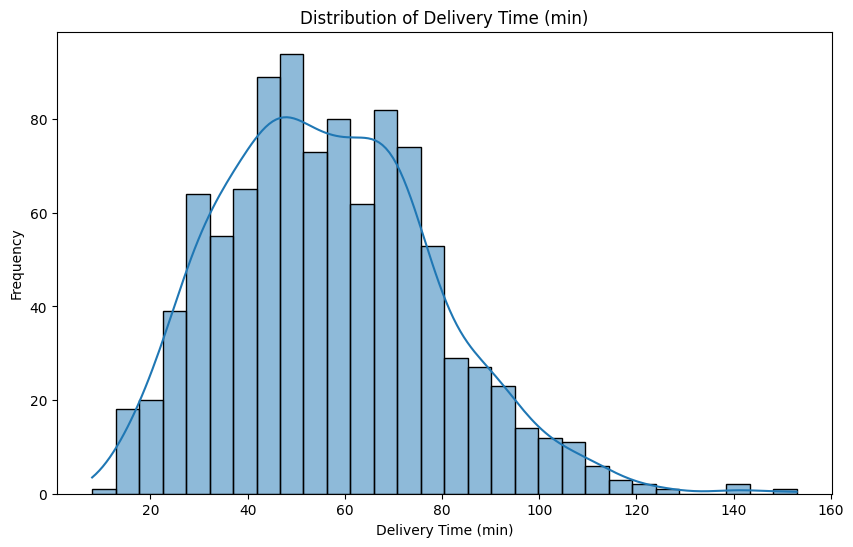

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(df['delivery_time_min'], bins=30, kde=True)
plt.title('Distribution of Delivery Time (min)')
plt.xlabel('Delivery Time (min)')
plt.ylabel('Frequency')
plt.show()

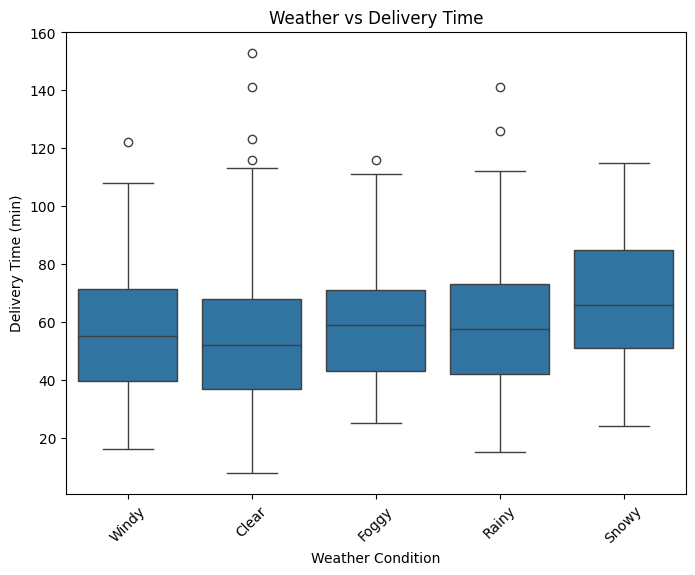

In [ ]:
plt.figure(figsize=(8,6))
sns.boxplot(x=df['weather'], y=df['delivery_time_min'])
plt.title("Weather vs Delivery Time")
plt.xlabel("Weather Condition")
plt.ylabel("Delivery Time (min)")
plt.xticks(rotation=45)
plt.show()

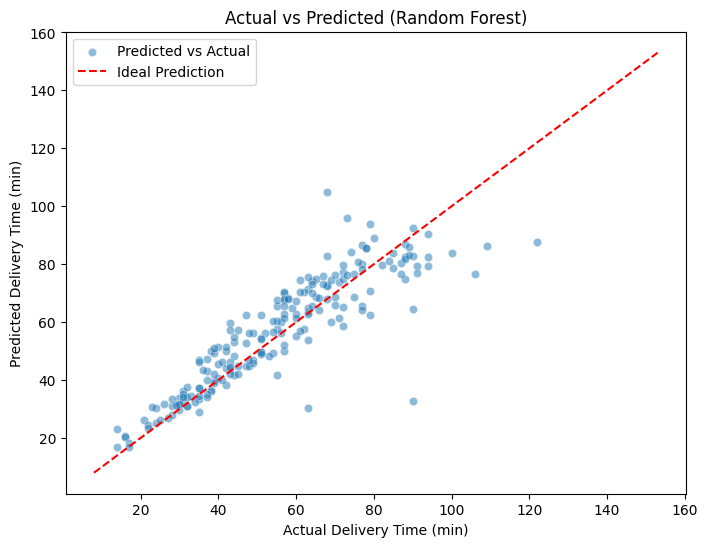

In [ ]:
plt.figure(figsize=(8,6))
sns.scatterplot(x=y_test, y=y_pred_rf, alpha=0.5, label='Predicted vs Actual')
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', label='Ideal Prediction')
plt.xlabel("Actual Delivery Time (min)")
plt.ylabel("Predicted Delivery Time (min)")
plt.title("Actual vs Predicted (Random Forest)")
plt.legend()
plt.show()

Calculate 'travel_time_min', subtract 'preparation_time_min' from 'delivery_time_min' and then ensure no negative values exist by replacing them with 0.



In [ ]:
df['travel_time_min'] = df['delivery_time_min'] - df['preparation_time_min']
df['travel_time_min'] = df['travel_time_min'].clip(lower=0)

print("Calculated 'travel_time_min' and ensured non-negative values.")
df[['delivery_time_min', 'preparation_time_min', 'travel_time_min']].head()

Calculated 'travel_time_min' and ensured non-negative values.


,delivery_time_min,preparation_time_min,travel_time_min
0,43,12,31
1,84,20,64
2,59,28,31
3,37,5,32
4,68,16,52


Group the DataFrame by 'traffic_level' and calculate the mean of 'preparation_time_min' and 'travel_time_min'.



In [ ]:
avg_times_by_traffic = df.groupby('traffic_level')[['preparation_time_min', 'travel_time_min']].mean().reset_index()

traffic_order = ['Low', 'Medium', 'High']
avg_times_by_traffic['traffic_level'] = pd.Categorical(avg_times_by_traffic['traffic_level'], categories=traffic_order, ordered=True)
avg_times_by_traffic = avg_times_by_traffic.sort_values('traffic_level')

print("Average preparation and travel times by traffic level:")
print(avg_times_by_traffic)

Average preparation and travel times by traffic level:
  traffic_level  preparation_time_min  travel_time_min
1           Low             17.227154        35.657963
2        Medium             16.873810        39.578571
0          High             16.736041        48.071066


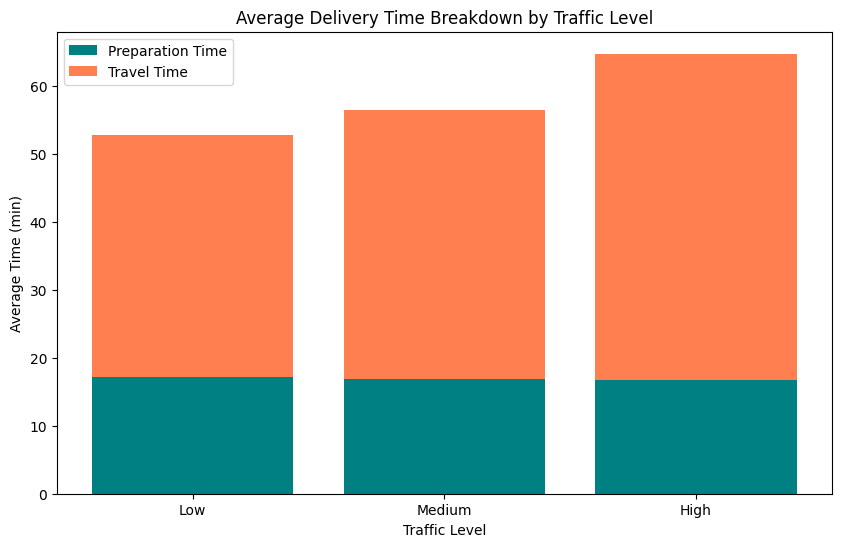

In [ ]:
plt.figure(figsize=(10, 6))

plt.bar(avg_times_by_traffic['traffic_level'], avg_times_by_traffic['preparation_time_min'], color='teal', label='Preparation Time')
plt.bar(avg_times_by_traffic['traffic_level'], avg_times_by_traffic['travel_time_min'], bottom=avg_times_by_traffic['preparation_time_min'], color='coral', label='Travel Time')

plt.xlabel('Traffic Level')
plt.ylabel('Average Time (min)')
plt.title('Average Delivery Time Breakdown by Traffic Level')
plt.legend()
plt.show()

Calculate 'delivery_speed_km_per_min', I will divide 'distance_km' by 'travel_time_min'. Handle potential infinite and NaN values by replacing them with 0 to ensure data integrity.



In [ ]:
df['delivery_speed_km_per_min'] = df['distance_km'] / df['travel_time_min']
df['delivery_speed_km_per_min'] = df['delivery_speed_km_per_min'].replace([np.inf, -np.inf], 0).fillna(0)

print("Calculated 'delivery_speed_km_per_min' and handled infinite/NaN values.")
df[['distance_km', 'travel_time_min', 'delivery_speed_km_per_min']].head()

Calculated 'delivery_speed_km_per_min' and handled infinite/NaN values.


,distance_km,travel_time_min,delivery_speed_km_per_min
0,7.93,31,0.255806
1,16.42,64,0.256563
2,9.52,31,0.307097
3,7.44,32,0.232500
4,19.03,52,0.365962


Visualize the distribution of delivery speed across different vehicle types, Create a swarm plot using seaborn


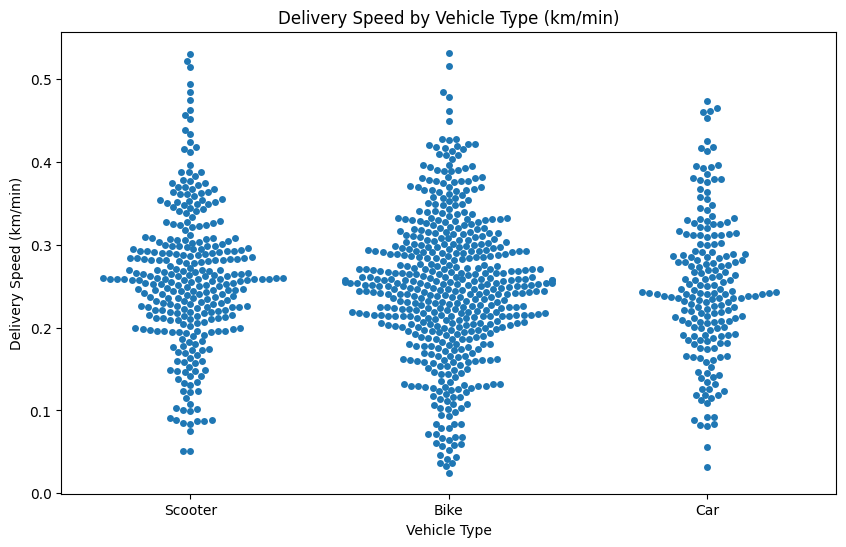

In [ ]:
plt.figure(figsize=(10, 6))
sns.swarmplot(x='vehicle_type', y='delivery_speed_km_per_min', data=df)
plt.title('Delivery Speed by Vehicle Type (km/min)')
plt.xlabel('Vehicle Type')
plt.ylabel('Delivery Speed (km/min)')
plt.show()